In [1]:
from keras.layers import Conv2D, MaxPool2D, Flatten

In [2]:
# FACE DETECTION & PREPROCESSING

import cv2
from mtcnn import MTCNN

detector = MTCNN()

def detect_face(img):

    # resize dulu agar ringan
    img = cv2.resize(img, (320, 240))

    # BGR ke RGB
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # deteksi wajah
    results = detector.detect_faces(rgb)

    # jika tidak ada wajah
    if len(results) == 0:
        return None

    # ambil wajah pertama
    x, y, w, h = results[0]['box']

    # hindari negatif
    x = max(0, x)
    y = max(0, y)

    # crop wajah
    face = rgb[y:y+h, x:x+w]
    
    # pastikan wajah tidak kosong
    if face.size == 0:
        return None

    # grayscale
    # face = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)

    # resize final
    face = cv2.resize(face, (100, 100))

    return face

In [3]:
def print_progress(val, val_len, folder, bar_size=20):
    progr = "#"*round((val)*bar_size/val_len) + " "*round((val_len - (val))*bar_size/val_len)
    if val == 0:
        print("", end = "\n")
    else:
        print("[%s] (%d samples)\t label : %s \t\t" % (progr, val+1, folder), end="\r")

In [4]:
# LOAD DATASET 

import gc
import os
import cv2
import random # tambahan Shuffle File

dataset_folder = "Dataset/Dataset_wajah"

names = []
images = []

for folder in os.listdir(dataset_folder):
    folder_path = os.path.join(dataset_folder, folder)
    if not os.path.isdir(folder_path):
        continue
    files = os.listdir(folder_path)
    random.shuffle(files)
    files = files[:80] # tambahan Batasi jumlah gambar per label

    for i, name in enumerate(files):
        if name.endswith(".JPG") or name.endswith(".jpg"):
            img_path = os.path.join(folder_path, name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (640, 480))
            
            img = detect_face(img)
            if img is not None:
                
                images.append(img)
                names.append(folder)
                print_progress(i, len(files), folder)
                
            # kosongkan variable img dari RAM
            del img

            # bersihkan memory
            gc.collect()
            
print("\nTotal images:", len(images))
print("Total labels:", len(names))


[####################] (80 samples)	 label : Faza Humairah 		
[####################] (80 samples)	 label : Jabbal Akbar 		
[####################] (79 samples)	 label : Muhammad Alif 		
[####################] (80 samples)	 label : Muhammad Heikal Fasya 		
[####################] (80 samples)	 label : Muhammad Rizki Arta Maulana 		
[####################] (80 samples)	 label : Muhammad Zahrul Ath Thariq 		
[####################] (80 samples)	 label : Nabila Balqis 		
[####################] (80 samples)	 label : Natasya Babulrhaiyan 		
[####################] (80 samples)	 label : Nur Fadhillah Zulfi 		
[####################] (80 samples)	 label : Putri Al Violy 		
[####################] (79 samples)	 label : Rahmat Isma Hidayat 		
[####################] (80 samples)	 label : Riski Maulani 		
[####################] (80 samples)	 label : Salesya Al Fatila 		
[####################] (80 samples)	 label : Suci Wildani Rizka 		
[####################] (80 samples)	 label : Syariqul Husni 		
[####

In [5]:
print("number of samples :", len(names))

number of samples : 1558


In [ ]:
# IMAGE AUGMENTATION

def img_augmentation(img):
    h, w = img.shape[:2] # ditambah karna pakai RGB
    center = (w // 2, h // 2)
    
    # rotation
    M_rot_5 = cv2.getRotationMatrix2D(center, 5, 1.0)
    M_rot_neg_5 = cv2.getRotationMatrix2D(center, -5, 1.0)
    
    #M_rot_10 = cv2.getRotationMatrix2D(center, 10, 1.0)
    #M_rot_neg_10 = cv2.getRotationMatrix2D(center, -10, 1.0)
    
    # translation
    M_trans_3 = np.float32([[1, 0, 3], [0, 1, 0]])
    M_trans_neg_3 = np.float32([[1, 0, -3], [0, 1, 0]])
    
    #M_trans_6 = np.float32([[1, 0, 6], [0, 1, 0]])
    #M_trans_neg_6 = np.float32([[1, 0, -6], [0, 1, 0]])
    #M_trans_y3 = np.float32([[1, 0, 0], [0, 1, 3]])
    #M_trans_neg_y3 = np.float32([[1, 0, 0], [0, 1, -3]])
    #M_trans_y6 = np.float32([[1, 0, 0], [0, 1, 6]])
    #M_trans_neg_y6 = np.float32([[1, 0, 0], [0, 1, -6]])

    imgs = []
    # rotate
    imgs.append(cv2.warpAffine(img, M_rot_5, (w, h)))
    imgs.append(cv2.warpAffine(img, M_rot_neg_5, (w, h)))

    # shift
    imgs.append(cv2.warpAffine(img, M_trans_3, (w, h)))
    imgs.append(cv2.warpAffine(img, M_trans_neg_3, (w, h)))

    # brightness ringan
    imgs.append(cv2.convertScaleAbs(img, alpha=1.0, beta=10))
    imgs.append(cv2.convertScaleAbs(img, alpha=1.0, beta=-10))
    
    # horizontal flip
    imgs.append(cv2.flip(img, 1))
    
    #imgs.append(cv2.warpAffine(img, M_rot_5, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_rot_neg_5, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_rot_10, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_rot_neg_10, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_trans_3, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_trans_neg_3, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_trans_6, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_trans_neg_6, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_trans_y3, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_trans_neg_y3, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_trans_y6, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.warpAffine(img, M_trans_neg_y6, (w, h), borderValue=(255,255,255)))
    #imgs.append(cv2.add(img, 10))
    #imgs.append(cv2.add(img, 30))
    #imgs.append(cv2.add(img, -10))
    #imgs.append(cv2.add(img, -30))
    #imgs.append(cv2.add(img, 15))
    #imgs.append(cv2.add(img, 45))
    #imgs.append(cv2.add(img, -15))
    #imgs.append(cv2.add(img, -45))

    return imgs

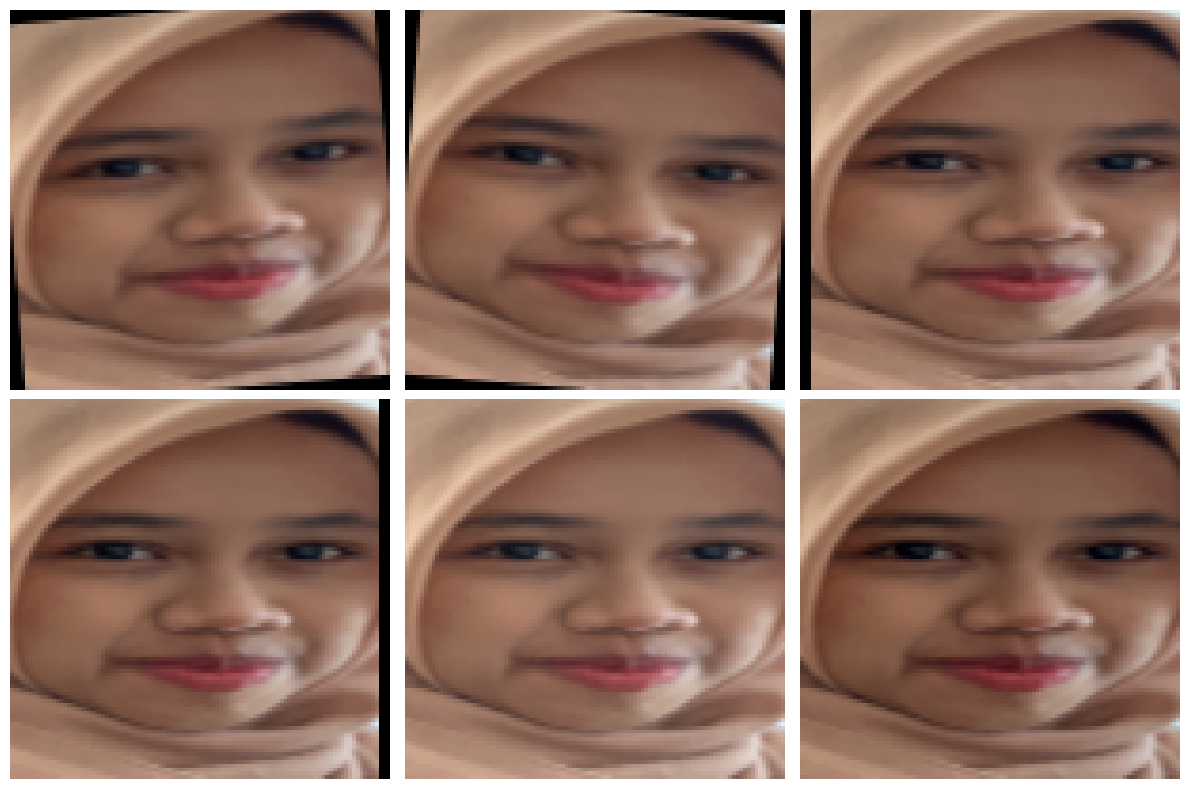

In [7]:
# VISUALISASI HASIL AUGMENTASI

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_test = images[0]

augmented_image_test = img_augmentation(img_test)


plt.figure(figsize=(12,8)) #(15,10)

for i, img in enumerate(augmented_image_test):
    plt.subplot(2,3,i+1)  # plt.subplot(4,5,i+1)
    plt.imshow(img) #(img, cmap="gray")
    plt.axis("off")
    
plt.tight_layout()
plt.show()

In [8]:
# Melakukan augmentasi ke seluruh dataset

augmented_images = []
augmented_names = []
for i, img in enumerate(images):
    try :
        aug_imgs = img_augmentation(img)
        augmented_images.extend(aug_imgs)
        augmented_names.extend([names[i]] * len(aug_imgs))
        
    except Exception as e:
        print(i, e)

In [9]:
# Mengecek jumlah data hasil augmentasi

print("Total augmented images :", len(augmented_images))
print("Total augmented labels :", len(augmented_names))

Total augmented images : 9348
Total augmented labels : 9348


In [10]:
# Menggabungkan dataset asli dengan dataset hasil augmentasi

images.extend(augmented_images)
names.extend(augmented_names)

# Mengecek jumlah total dataset setelah penggabungan data asli dan data augmentasi
print("Final total images :", len(images))
print("Final total labels :", len(names))

# bersihkan memory
del augmented_images
del augmented_names

gc.collect()

Final total images : 10906
Final total labels : 10906


10336

In [11]:
# Menghitung jumlah data pada setiap label di dataset

unique, counts = np.unique(names, return_counts = True)
for label, total in zip(unique, counts):
    
    print(f"{label} : {total} images")

#for item in zip(unique, counts):
    #print(item)

Faza Humairah : 553 images
Jabbal Akbar : 518 images
Muhammad Alif : 532 images
Muhammad Heikal Fasya : 560 images
Muhammad Rizki Arta Maulana : 560 images
Muhammad Zahrul Ath Thariq : 546 images
Nabila Balqis : 553 images
Natasya Babulrhaiyan : 532 images
Nur Fadhillah Zulfi : 553 images
Putri Al Violy : 560 images
Rahmat Isma Hidayat : 539 images
Riski Maulani : 532 images
Salesya Al Fatila : 525 images
Suci Wildani Rizka : 560 images
Syariqul Husni : 546 images
Syifaurrahman : 553 images
Tasya Anisa : 532 images
Urfi Shanda : 560 images
Vivi Jumilia Hikmah : 553 images
Zuyyin Zafirah : 539 images


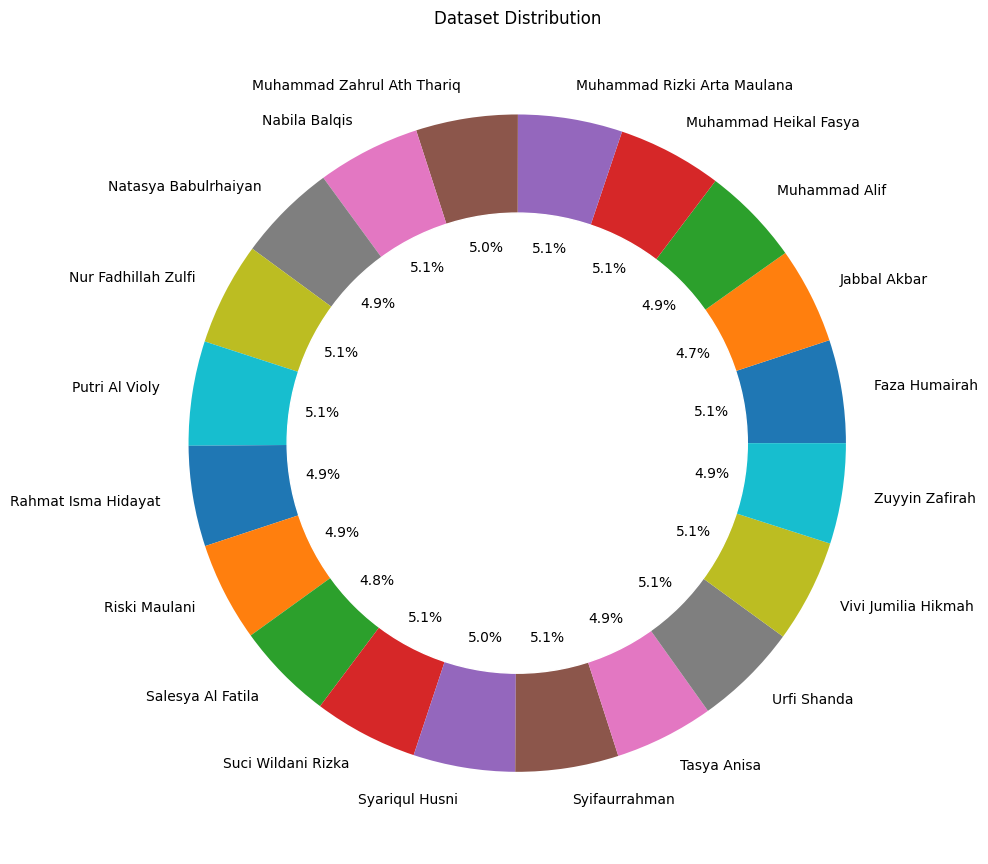

In [12]:
# BALANCING DATA
# Visualisasi distribusi dataset

def print_data(label_distr, label_name):
    plt.figure(figsize=(10,10))

    my_circle = plt.Circle( (0,0), 0.7, color='white')
    
    plt.pie(label_distr, labels=label_name, autopct='%1.1f%%')
    plt.gcf().gca().add_artist(my_circle)
    plt.title("Dataset Distribution")
    plt.tight_layout()
    plt.show()
    
unique, counts = np.unique(names, return_counts=True)
print_data(counts, unique)

In [13]:
# Encoding Label & Categoricalization
# Mengubah label nama peserta menjadi format numerik dan kategorikal

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import pickle

# inisialisasi label encoder
le = LabelEncoder()

# encoding label nama menjadi angka
name_vec = le.fit_transform(names)

# menyimpan nama class
labels = le.classes_

# konversi ke one-hot encoding
categorical_name_vec = to_categorical(name_vec)

# SAVE LABEL ENCODER 

with open(
    "Label_encoder_cnn.pickle",
    "wb"
) as f:

    pickle.dump(le, f)

print("[INFO] Label encoder berhasil disimpan.")

[INFO] Label encoder berhasil disimpan.


In [14]:
# Menampilkan jumlah kelas dan nama seluruh kelas/label pada dataset

print(f"Number of classes : {len(labels)}")
print("\nClass Labels :")

for i, label in enumerate(labels):
    print(f"{i} : {label}")

Number of classes : 20

Class Labels :
0 : Faza Humairah
1 : Jabbal Akbar
2 : Muhammad Alif
3 : Muhammad Heikal Fasya
4 : Muhammad Rizki Arta Maulana
5 : Muhammad Zahrul Ath Thariq
6 : Nabila Balqis
7 : Natasya Babulrhaiyan
8 : Nur Fadhillah Zulfi
9 : Putri Al Violy
10 : Rahmat Isma Hidayat
11 : Riski Maulani
12 : Salesya Al Fatila
13 : Suci Wildani Rizka
14 : Syariqul Husni
15 : Syifaurrahman
16 : Tasya Anisa
17 : Urfi Shanda
18 : Vivi Jumilia Hikmah
19 : Zuyyin Zafirah


In [15]:
# Menampilkan label numerik hasil encoding nama peserta

print("Label Mapping :")
for i, label in enumerate(labels):
    print(f"{label} -> {i}")

Label Mapping :
Faza Humairah -> 0
Jabbal Akbar -> 1
Muhammad Alif -> 2
Muhammad Heikal Fasya -> 3
Muhammad Rizki Arta Maulana -> 4
Muhammad Zahrul Ath Thariq -> 5
Nabila Balqis -> 6
Natasya Babulrhaiyan -> 7
Nur Fadhillah Zulfi -> 8
Putri Al Violy -> 9
Rahmat Isma Hidayat -> 10
Riski Maulani -> 11
Salesya Al Fatila -> 12
Suci Wildani Rizka -> 13
Syariqul Husni -> 14
Syifaurrahman -> 15
Tasya Anisa -> 16
Urfi Shanda -> 17
Vivi Jumilia Hikmah -> 18
Zuyyin Zafirah -> 19


In [16]:
# Menampilkan label dalam bentuk One-Hot Encoding

print("Sample one-hot encoded labels :")
print(categorical_name_vec[:10])

print("Shape :", categorical_name_vec.shape)

Sample one-hot encoded labels :
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Shape : (10906, 20)


In [17]:
# SPLIT DATASET
# Membagi dataset menjadi data training dan data testing

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    np.array(images, dtype=np.float32),
    np.array(categorical_name_vec),
    test_size=0.20,
    random_state=42,
    stratify=name_vec
)

print("x_train shape :", x_train.shape)
print("y_train shape :", y_train.shape)

print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

x_train shape : (8724, 100, 100, 3)
y_train shape : (8724, 20)
x_test shape : (2182, 100, 100, 3)
y_test shape : (2182, 20)


In [18]:
# RESHAPE DATASET
# Normalisasi pixel image ke rentang 0-1

x_train = x_train / 255.0
x_test = x_test / 255.0

print("x_train shape :", x_train.shape)
print("x_test shape :", x_test.shape)

# Mengubah bentuk (reshape) data gambar agar sesuai dengan format input CNN.

#x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
#x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

#x_train.shape, x_test.shape

#x_train = x_train / 255.0
#x_test = x_test / 255.0

x_train shape : (8724, 100, 100, 3)
x_test shape : (2182, 100, 100, 3)


In [19]:
# CNN MODEL ARCHITECTURE 

# Import library untuk membangun model CNN
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,        # Layer konvolusi untuk ekstraksi fitur wajah
    MaxPool2D,     # Layer pooling untuk mengurangi dimensi fitur
    Flatten,       # Mengubah feature map menjadi vektor 1 dimensi
    Dense,         # Fully connected layer
    Activation,    # Fungsi aktivasi output
    Dropout,        # Mengurangi overfitting
    BatchNormalization
)

# Function untuk membangun model CNN
def cnn_model(input_shape):  
    
    # Membuat model sequential
    model = Sequential()
    
    # FEATURE EXTRACTION LAYER
    
    # Convolution layer pertama
    model.add(Conv2D(
                    32,
                    (3,3),
                    padding="same",
                    activation="relu",
                    input_shape=input_shape))
    
    model.add(BatchNormalization())
    
    model.add(Conv2D(
                    32,
                    (3,3),
                    padding="same",
                    activation="relu",
                    input_shape=input_shape))
    
    model.add(BatchNormalization())
    
    # Max pooling layer
    model.add(MaxPool2D(pool_size=(2, 2)))
    
    model.add(Dropout(0.25))
    
    # Convolution layer dua
    model.add(Conv2D(
                    64,
                    (3,3),
                    padding="same",
                    activation="relu"))
    
    model.add(Conv2D(
                    64,
                    (3,3),
                    padding="same",
                    activation="relu"))
    
    model.add(BatchNormalization())
    
    # Max pooling layer
    model.add(MaxPool2D(pool_size=(2, 2)))
    
    model.add(Dropout(0.25))
    
    # CLASSIFICATION LAYER 
    
    # Mengubah feature map menjadi vector
    model.add(Flatten())
    
    # Fully connected layer
    model.add(Dense(128, activation="relu"))
    
    model.add(Dropout(0.25))
    
    # Output layer sesuai jumlah class/label wajah
    model.add(Dense(len(labels)))
    
    # Aktivasi softmax untuk multiclass classification
    model.add(Activation("softmax"))
    
    
    # COMPILE MODEL
    
    # Menampilkan arsitektur model
    model.summary() 

    model.compile(
                optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy']
    )

    return model

In [20]:
# TRAINING MODEL CNN

from tensorflow.keras.callbacks import EarlyStopping

# input shape CNN
input_shape = x_train[0].shape

# hyperparameter
EPOCHS = 8
BATCH_SIZE = 32

# callback early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# build model
model = cnn_model(input_shape)

# training model
history = model.fit(x_train, 
                    y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    shuffle=True,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=1
                    )

d:\FaceAttend_VC\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,120,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,188,788 (19.79 MB)

 Trainable params: 5,188,532 (19.79 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 190s 838ms/step - accuracy: 0.7768 - loss: 1.2468 - val_accuracy: 0.0819 - val_loss: 62.1836
Epoch 2/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 175s 797ms/step - accuracy: 0.9256 - loss: 0.2787 - val_accuracy: 0.7897 - val_loss: 1.4113
Epoch 3/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 192s 876ms/step - accuracy: 0.9582 - loss: 0.1602 - val_accuracy: 0.9605 - val_loss: 0.2262
Epoch 4/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 202s 874ms/step - accuracy: 0.9553 - loss: 0.1964 - val_accuracy: 0.7467 - val_loss: 2.6292
Epoch 5/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 198s 904ms/step - accuracy: 0.9712 - loss: 0.1170 - val_accuracy: 0.8264 - val_loss: 1.9141


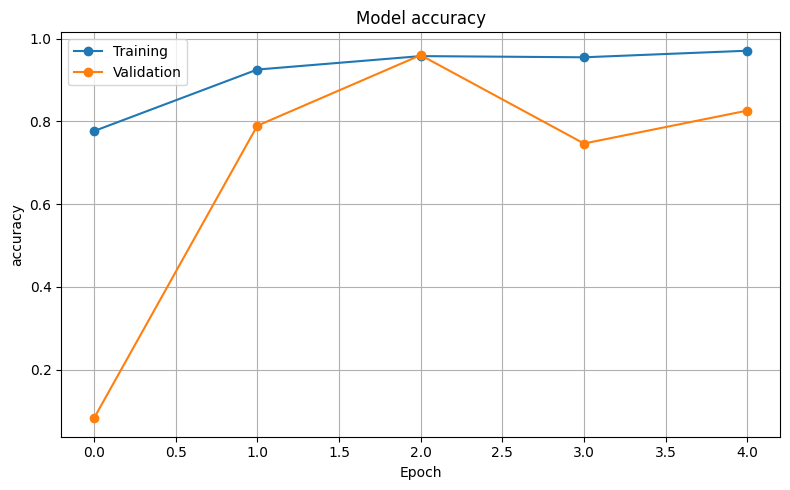

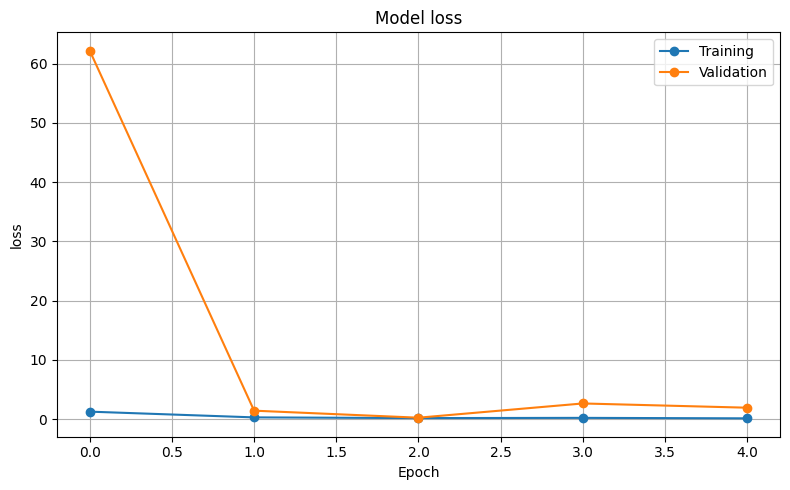

In [21]:
def evaluate_model(history):
    metrics = [
        ['accuracy', 'val_accuracy'],
        ['loss', 'val_loss']
    ]
    
    for metric in metrics:
        plt.figure(figsize=(8,5))
        plt.plot(
            history.history[metric[0]],
            marker='o'
        )

        plt.plot(
            history.history[metric[1]],
            marker='o'
        )

        plt.xlabel('Epoch')
        plt.ylabel(metric[0])
        plt.title('Model ' + metric[0])
        plt.legend(
            ['Training', 'Validation'],
            loc='best'
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

evaluate_model(history)

In [22]:
model.save("model-cnn-facerecognition.keras")

In [23]:
# Melakukan prediksi pada data testing menggunakan model CNN

y_pred = model.predict(
    x_test,
    verbose=0
)

In [24]:
# CONFUSION MATRIX

import itertools

def plot_confusion_matrix(
    cm,
    classes,
    normalize=False,
    title='Confusion Matrix',
    cmap=plt.cm.Blues
):

    # normalisasi confusion matrix
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12,10))
    plt.imshow(
        cm,
        interpolation='nearest',
        cmap=cmap
    )

    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))

    plt.xticks(
        tick_marks,
        classes,
        rotation=90,
        fontsize=8
    )

    plt.yticks(
        tick_marks,
        classes,
        fontsize=8
    )

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(
        range(cm.shape[0]),
        range(cm.shape[1])
    ):

        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=7
        )

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

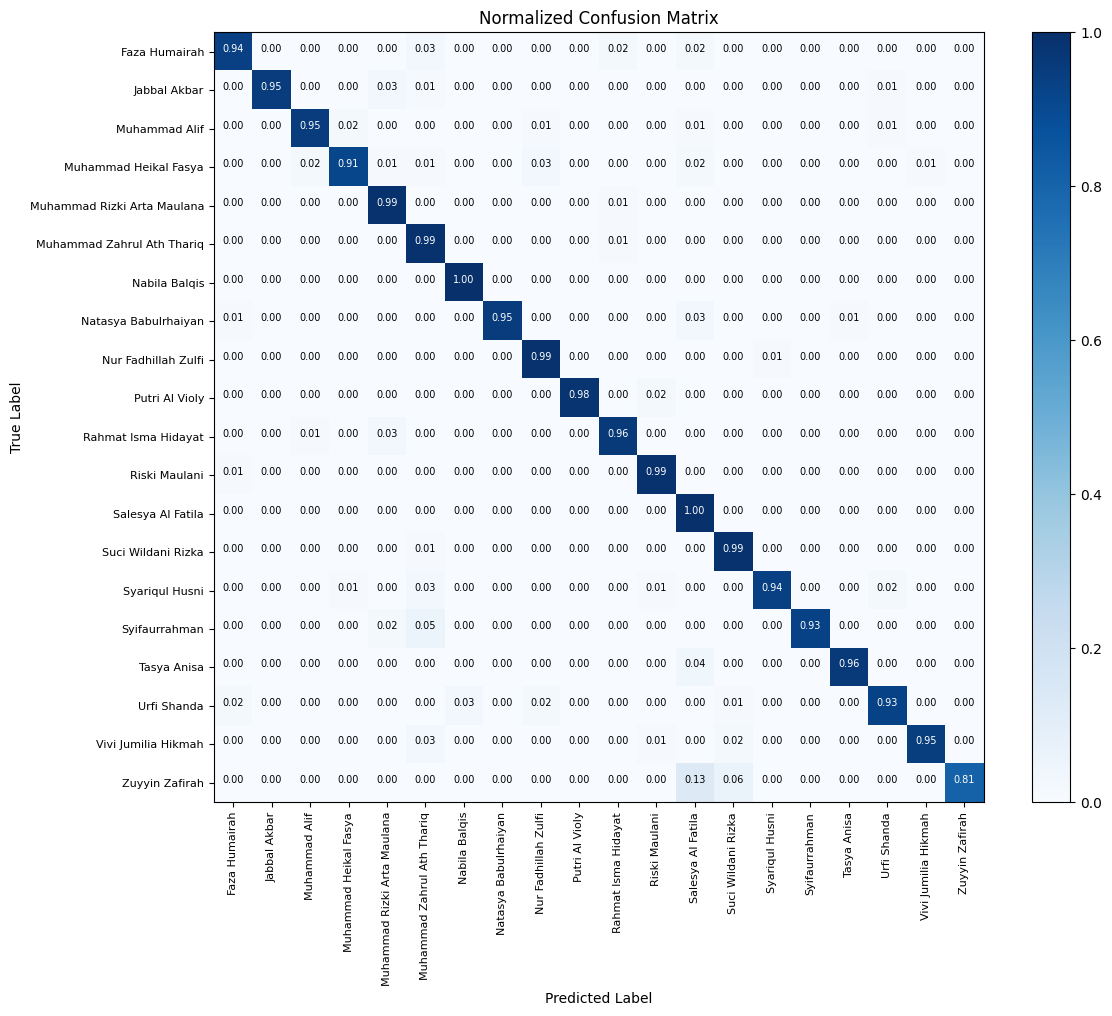

In [25]:
from sklearn.metrics import confusion_matrix
import itertools

# menghitung confusion matrix
cnf_matrix = confusion_matrix(
    y_test.argmax(axis=1),
    y_pred.argmax(axis=1)
)

# menampilkan angka desimal
np.set_printoptions(precision=2)

# visualisasi confusion matrix
plot_confusion_matrix(
    cnf_matrix,
    classes=labels,
    normalize=True,
    title='Normalized Confusion Matrix'
)


In [26]:
# Menampilkan hasil evaluasi klasifikasi model CNN

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

report = classification_report(
    y_test.argmax(axis=1),
    y_pred.argmax(axis=1),
    target_names=labels,
    zero_division=0
)

print(report)

                             precision    recall  f1-score   support

              Faza Humairah       0.96      0.94      0.95       111
               Jabbal Akbar       1.00      0.95      0.98       104
              Muhammad Alif       0.97      0.95      0.96       106
      Muhammad Heikal Fasya       0.97      0.91      0.94       112
Muhammad Rizki Arta Maulana       0.93      0.99      0.96       112
 Muhammad Zahrul Ath Thariq       0.86      0.99      0.92       109
              Nabila Balqis       0.97      1.00      0.99       111
       Natasya Babulrhaiyan       1.00      0.95      0.98       106
        Nur Fadhillah Zulfi       0.95      0.99      0.97       111
             Putri Al Violy       1.00      0.98      0.99       112
        Rahmat Isma Hidayat       0.96      0.96      0.96       108
              Riski Maulani       0.96      0.99      0.98       106
          Salesya Al Fatila       0.80      1.00      0.89       105
         Suci Wildani Rizka      

In [ ]:
import cv2
import numpy as np
from mtcnn import MTCNN
from tensorflow.keras.models import load_model

# ================= LOAD MODEL =================

detector = MTCNN()

model = load_model("model-cnn-facerecognition.keras")

print("[INFO] finish load model...")

# ================= OPEN CAMERA =================

cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # BGR -> RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # deteksi wajah
    results = detector.detect_faces(rgb)

    for result in results:

        x, y, w, h = result['box']

        # hindari koordinat negatif
        x = max(0, x)
        y = max(0, y)

        # crop wajah
        face = rgb[y:y+h, x:x+w]

        # validasi crop
        if face.size == 0:
            continue

        # resize sesuai training
        face = cv2.resize(face, (100, 100))

        # normalisasi
        face = face.astype("float32") / 255.0

        # reshape untuk CNN RGB
        face = face.reshape(1, 100, 100, 3)

        # prediksi
        result_pred = model.predict(
            face,
            verbose=0
        )

        idx = np.argmax(result_pred)
        confidence = np.max(result_pred) * 100
        print(labels[idx], confidence)

        # threshold recognition
        if confidence > 75:

            label_text = "%s (%.2f%%)" % (
                labels[idx],
                confidence
            )

        else:

            label_text = "Unknown"

        # bounding box
        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (0,255,255),
            2
        )

        # label text
        cv2.putText(
            frame,
            label_text,
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,255),
            2
        )

    cv2.imshow(
        "Face Recognition",
        frame
    )

    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

[INFO] finish load model...
Tasya Anisa 96.15834
Riski Maulani 100.0
Salesya Al Fatila 100.0
Riski Maulani 100.0
Salesya Al Fatila 99.999916
Riski Maulani 99.999985
Salesya Al Fatila 92.03441
Salesya Al Fatila 99.99777
Salesya Al Fatila 99.999985
Salesya Al Fatila 99.91148
Salesya Al Fatila 99.99998
Jabbal Akbar 99.984695
Salesya Al Fatila 89.33551
Salesya Al Fatila 100.0
Suci Wildani Rizka 75.59633
Salesya Al Fatila 76.52114
Nabila Balqis 76.56592
Suci Wildani Rizka 99.65193
Salesya Al Fatila 44.935078
Suci Wildani Rizka 73.98084
Salesya Al Fatila 99.99983
Salesya Al Fatila 47.005875
Salesya Al Fatila 99.98521
Salesya Al Fatila 100.0
Salesya Al Fatila 58.936016
Salesya Al Fatila 99.97051
Salesya Al Fatila 83.58695
Salesya Al Fatila 99.999535
Syifaurrahman 98.7383
Syifaurrahman 78.17066
Syifaurrahman 99.94958
Syifaurrahman 99.01702
Syifaurrahman 95.340256
Vivi Jumilia Hikmah 88.21498
Syifaurrahman 99.942635
Syifaurrahman 68.070465
Syifaurrahman 97.67131
Syifaurrahman 99.23607
Syifaurra